In [21]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

base_dir = os.path.dirname(os.getcwd())
images_dir = os.path.join(base_dir, 'images')

sns.set_theme(style="whitegrid")


engine = sqlite3.connect('../database/ecommerce.db')


tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", engine)
print("Available tables:", tables['name'].tolist())

Available tables: ['orders', 'order_items', 'products', 'customers']


# Part 1: Finance & Business Scale (Macro View)


## 1.1 Monthly Sales Trend
**Business Question:** How has the order volume evolved on a monthly basis over the past year?

In [22]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    SUM(oi.price) AS revenue
FROM orders o
JOIN order_items oi on oi.order_id = o.order_id
WHERE order_status = 'delivered'
      AND month NOT IN ('2018-09', '2018-10')
GROUP BY month
ORDER BY month ASC;
"""
df_trend = pd.read_sql_query(query, engine)
df_trend.head()

,month,revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


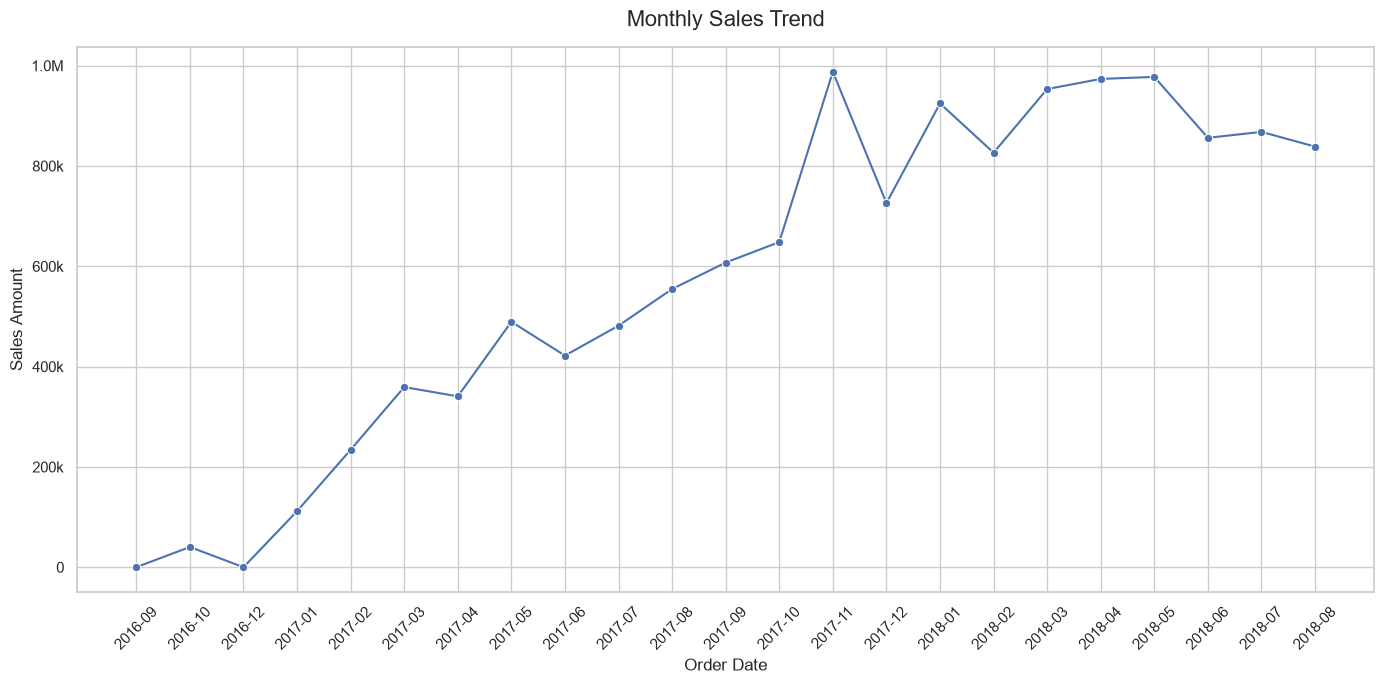

In [23]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    x='month',
    y='revenue',
    data=df_trend,
    marker='o',
    )

plt.title('Monthly Sales Trend', fontsize=16, pad=15)
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Sales Amount', fontsize=12)
plt.xticks(rotation=45)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}k' if x >= 1e3 else f'{x:.0f}'))

plt.tight_layout()

plt.savefig(os.path.join(images_dir, 'Monthly_Sales_Trend.png'))
plt.show()



#### Key Insights - Monthly Sales Trend
* **Aggresive growth (2017):** From January 2017 to October 2017, the platform experienced **stable, nearly linear revenue growth** - surging from a level of **100k BRL** to over **600k BRL**.
* **The Black Friday Spike (2017-11):** In November 2017, there is a massive, sharp peak where revenue almost touched the **1M BRL** mark. This represents the absolute historical record for the platform due to seasonal Black Friday promotions.
* **Post-Holiday Stabilization (2018):** After a typical December drop, the revenue in 2018 shifted from aggressive growth into a **high-volume plateau**, stabilizing consistently between **850k BRL and 1M BRL** per month until August 2018.
* **Methodological Data Cutoff (August 2018):** The timeline intentionally excludes September and October 2018. In the raw Olist dataset, these trailing months contain incomplete order records, which causes a artificial, near-zero drop on a full timeline. To prevent this technical distortion from showing a false business collapse, the data was strictly filtered to end at August 2018, ensuring a clean and accurate view of the revenue plateau.

# Part 2: Sales Structure & Payment Mechanics

## 2.1 Top Product Categories
**Business Question:** What are the top product categories in terms of order volume and total revenue?

In [24]:
query_volume='''
SELECT
    p.product_category_name AS category,
    SUM(oi.order_item_id) AS order_volume
FROM order_items oi
JOIN orders o on oi.order_id = o.order_id
JOIN products p on oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY order_volume DESC
LIMIT 10;
'''

query_revenue='''
SELECT
    p.product_category_name AS category,
    SUM(oi.price) AS total_revenue
FROM order_items oi
JOIN orders o on oi.order_id = o.order_id
JOIN products p on oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;
'''
df_volume=pd.read_sql(query_volume, engine)
df_revenue=pd.read_sql(query_revenue, engine)

print(df_volume.head())
print(df_revenue.head())


                 category  order_volume
0         cama_mesa_banho         13485
1        moveis_decoracao         11302
2            beleza_saude         10849
3           esporte_lazer          9698
4  informatica_acessorios          9650
                 category  total_revenue
0            beleza_saude     1233131.72
1      relogios_presentes     1166176.98
2         cama_mesa_banho     1023434.76
3           esporte_lazer      954852.55
4  informatica_acessorios      888724.61


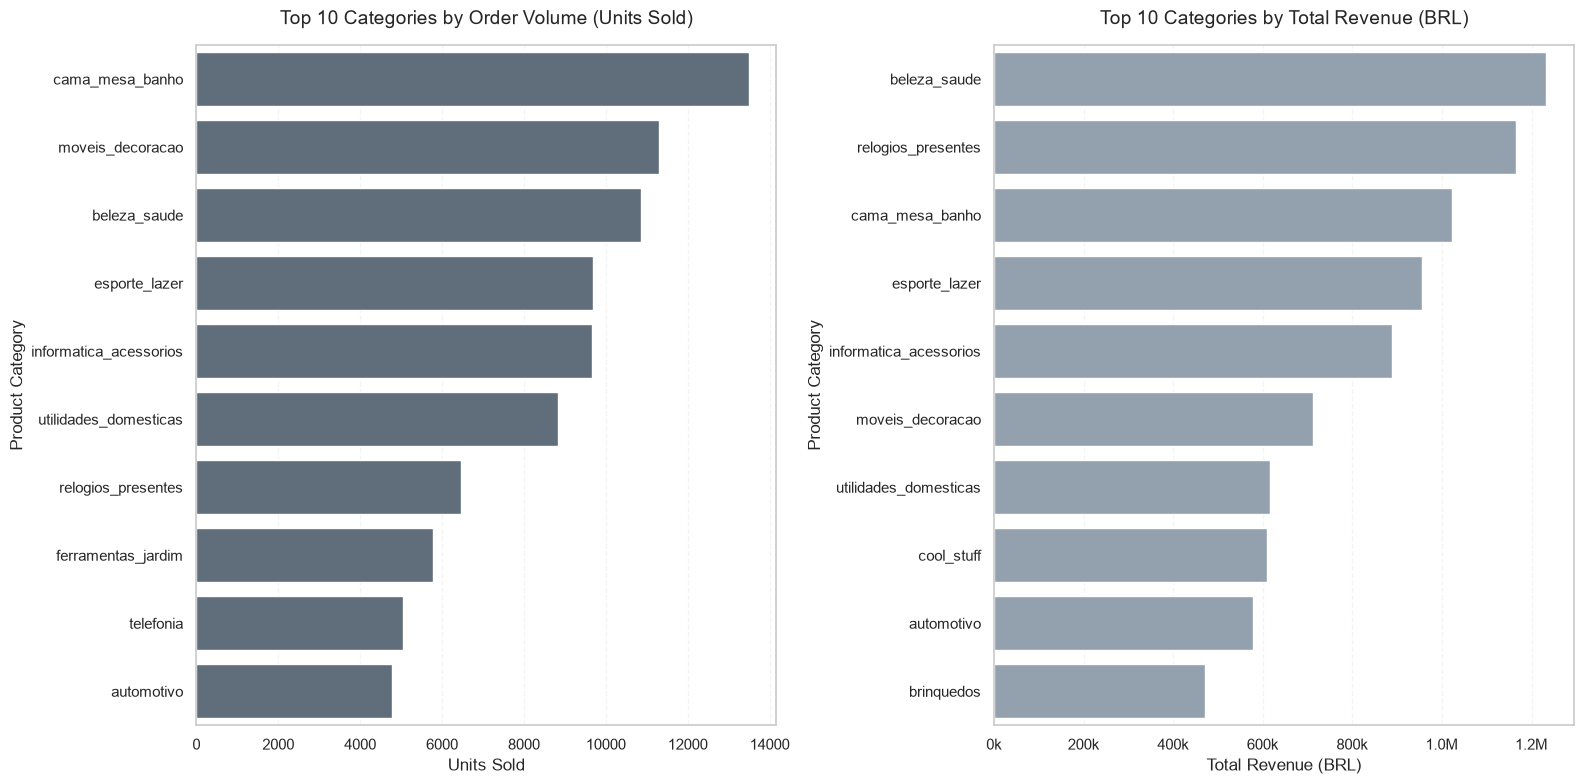

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(
    x='order_volume',
    y='category',
    data=df_volume,
    color='#5b6d80',
    ax=ax1
)
ax1.set_title('Top 10 Categories by Order Volume (Units Sold)', fontsize=14, pad=15)
ax1.set_xlabel('Units Sold', fontsize=12)
ax1.set_ylabel('Product Category', fontsize=12)
ax1.grid(axis='x', linestyle='--', alpha=0.2)

sns.barplot(
    x='total_revenue',
    y='category',
    data=df_revenue,
    color='#8fa1b3',
    ax=ax2
)
ax2.set_title('Top 10 Categories by Total Revenue (BRL)', fontsize=14, pad=15)
ax2.set_xlabel('Total Revenue (BRL)', fontsize=12)
ax2.set_ylabel('Product Category', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.2)


ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}k'))

plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'Top_Product_Categories.png'), dpi=300)
plt.show()

### Key Insights - Top Product Categories (Volume vs. Revenue)

* **The Transactional Leader:** `cama_mesa_banho` (bed_bath_table) is the absolute volume driver on the platform, ranking #1 in units sold. However, it drops to #3 in total revenue, showing it relies heavily on high-frequency, mid-to-low ticket sales.
* **The High-Value Heavyweight:** `beleza_saude` (health_beauty) is the ultimate crown jewel for Olist. It holds a strong #3 position in order volume but completely dominates as the #1 driver of **Total Revenue**, indicating a perfect mix of high demand and solid average ticket prices.
* **Pure Premium Players:** Categories like `relogios_presentes` (watches_gifts) perfectly showcase the high-AOV (Average Order Value) effect. It ranks much lower at #7 in volume, but skyrockets to **#2 in total revenue**, proving that fewer transactions of premium goods heavily scale the platform's GMV.
* **The Hidden Revenue Drivers:** By decoupling volume and revenue into two separate queries, we successfully uncovered categories like `cool_stuff` and `brinquedos` (toys) on the revenue leaderboard. These categories don't move enough units to enter the top volume tier, but their high product values make them essential financial pillars for the marketplace.

## 3.1 Logistics Performance
**Business Question:** What is the average delivery time across different Brazilian states, and where do the biggest delays occur?

In [26]:
query = """
SELECT
    c.customer_state,
    (julianday(o.order_delivered_customer_date)-julianday(o.order_purchase_timestamp)) AS delivery_time_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

df_logistics = pd.read_sql_query(query, engine)


df_logistics.head()

,customer_state,delivery_time_days
0,SP,8.436574
1,BA,13.782037
2,GO,9.394213
3,RN,13.208750
4,SP,2.873877


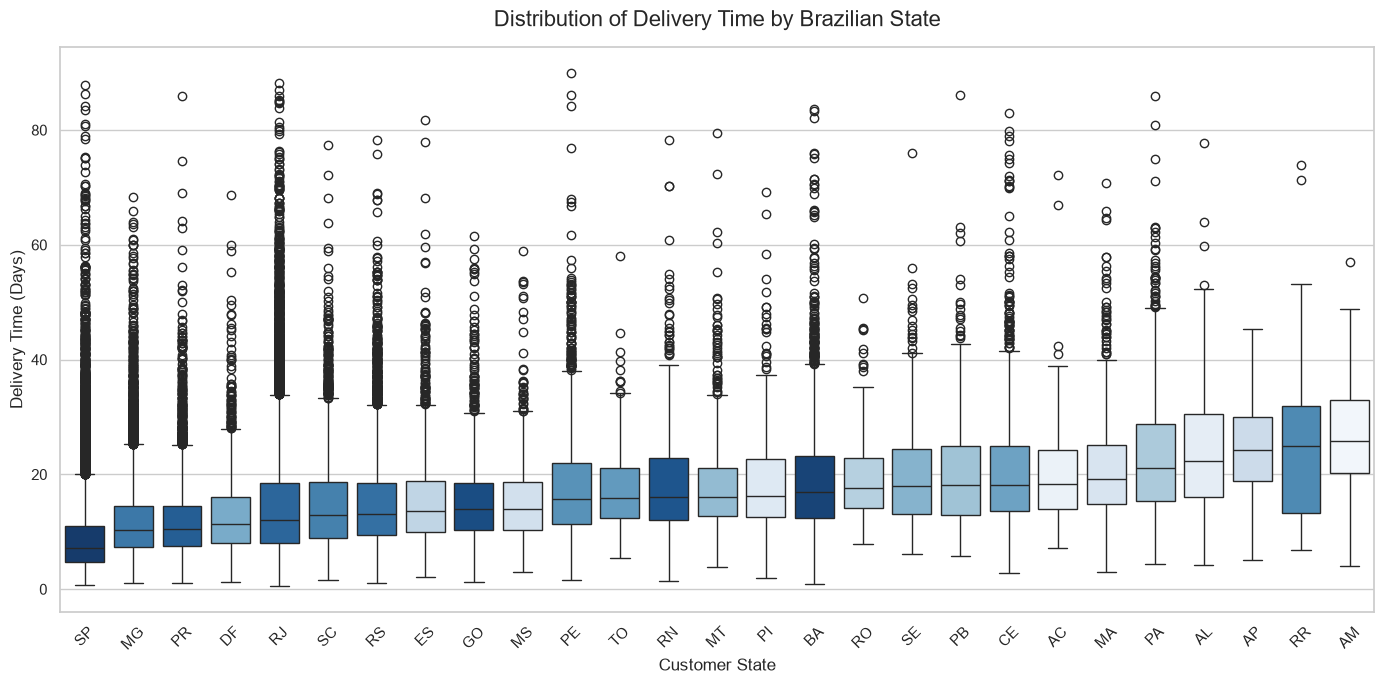

In [27]:

df_filtered = df_logistics[df_logistics['delivery_time_days'] <= 90]


state_order = df_filtered.groupby('customer_state')['delivery_time_days'].median().sort_values().index


plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_filtered,
    x='customer_state',
    y='delivery_time_days',
    order=state_order,
    hue='customer_state',
    legend=False,
    palette="Blues_r"
)

plt.title('Distribution of Delivery Time by Brazilian State', fontsize=16, pad=15)
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Delivery Time (Days)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(images_dir, 'Logistics_Performance.png'))
plt.show()

### Key Insights - Logistics Performance

* **The Efficiency Leaders:** The economic heart of Brazil (**SP** - São Paulo) clearly dominates with the lowest median delivery time, sitting well under **10 days**. Neighboring states like **MG** (Minas Gerais), **PR** (Paraná), and **DF** (Distrito Federal) also maintain highly efficient networks with medians around 10–12 days.
* **Severe Northern Delays:** As we move towards the right side of the chart, delivery times spike dramatically. States like **AP** (Amapá), **RR** (Roraima), and **AM** (Amazonas) suffer from the worst logistics bottlenecks, with median delivery times hovering between **20 and 30 days**, and whole boxes stretched much higher.
* **The "Outlier Storm":** Looking at **SP** and **RJ** (Rio de Janeiro), there is a massive vertical tower of individual outlier points (white circles) stretching all the way up to **80+ days**. This reveals a critical business problem: even though São Paulo is normally fast, it experiences a high absolute volume of severe logistics failures.
* **High Volatility in Remote Regions:** States like **RR** and **AM** not only have high medians but also much taller "boxes" (interquartile range). This means shipping to these locations is highly unpredictable for the customer compared to the tight, predictable boxes of **SP** or **PR**.
* **Methodological Note (Fulfillment vs. Transit):** This analysis tracks the *total* time from purchase to delivery. To precisely isolate whether northern delays are caused by local courier infrastructure or slow merchant packaging (fulfillment), a separate analysis tracking only the transit window (`order_delivered_customer_date` minus `order_delivered_carrier_date`) should be conducted.